### step 1: Import dataset.

In [2]:
import pandas as pd

df = pd.read_csv("./fake_or_real_news.csv")
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",FAKE
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,FAKE
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,REAL
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",FAKE
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,REAL


### step 2: Fix the datasets.
This step may include feature extraction, converting text label into numeric label, and so on.

In [3]:
df["label"] = df["label"].map({"FAKE":0, "REAL":1})
df.head()

,Unnamed: 0,title,text,label
0,8476,You Can Smell Hillary’s Fear,"Daniel Greenfield, a Shillman Journalism Fello...",0
1,10294,Watch The Exact Moment Paul Ryan Committed Pol...,Google Pinterest Digg Linkedin Reddit Stumbleu...,0
2,3608,Kerry to go to Paris in gesture of sympathy,U.S. Secretary of State John F. Kerry said Mon...,1
3,10142,Bernie supporters on Twitter erupt in anger ag...,"— Kaydee King (@KaydeeKing) November 9, 2016 T...",0
4,875,The Battle of New York: Why This Primary Matters,It's primary day in New York and front-runners...,1


Lets find the Longest and Smallest text.

In [14]:
length_reviews = df.text.str.len()
longest_txt = max(length_reviews)
smallest_txt = min(length_reviews)
longest_txt.__index__(),smallest_txt.__index__()

(115372, 1)

In [4]:
# just check whether it predicts correctly or not.
n = 2063
df["label"][n], df["text"][n]

(1,
 'Mothers whose children have been killed by police officers marched in Washington, D.C., on Saturday to call attention to police brutality and racial injustice.\n\nThe Million Moms March was sponsored by Mothers for Justice United, an organization of mothers whose children have been killed by police officers and others, and the Coalition for Justice. The march moved from the U.S. Capitol to the U.S. Department of Justice, where demonstrators demanded changes in police practices.\n\nMaria Hamilton founded Mothers for Justice United and helped organize the march of mothers and their supporters. Hamilton\'s 31-year-old son, Dontre Hamilton, was shot 14 times and killed by a former Milwaukee police officer.\n\n"This is a call for everybody to wake up," Hamilton said as the march began Saturday afternoon. "We are here on behalf of our babies to tell the United States government that we aren\'t going anywhere. We aren\'t going to continue to keep burying our babies. Do something and do 

In [5]:
df['label'].value_counts()

label
1    3171
0    3164
Name: count, dtype: int64

### step 3:Convert the dataset into training and test splits. Then vectorize them, fit transform training data and transform test data.

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split

y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(df["text"],y, test_size=0.33, random_state=42)
count_vectorizer = CountVectorizer(stop_words="english", max_df=0.7)

count_train = count_vectorizer.fit_transform(X_train.values)
count_test = count_vectorizer.transform(X_test.values)

### step 4: use a classifier to classify the real or fake news. Here we are using MultinomialNB which is popular classifier from Naive Bayes. It performs better than Logistic Regression.

In [21]:
from sklearn.naive_bayes import MultinomialNB

model = MultinomialNB()
model.fit(count_train, y_train)

y_predict = model.predict(count_test)

### step 5: Use different metrics to check the model performance.

In [28]:
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print(f"Accuracy: {accuracy_score(y_test, y_predict)*100:.3f}%")
print(classification_report(y_test, y_predict))

Accuracy: 88.857%
              precision    recall  f1-score   support

           0       0.92      0.85      0.89      1071
           1       0.86      0.93      0.89      1020

    accuracy                           0.89      2091
   macro avg       0.89      0.89      0.89      2091
weighted avg       0.89      0.89      0.89      2091



In [30]:
print(confusion_matrix(y_test, y_predict,labels=[0,1]))

[[913 158]
 [ 75 945]]


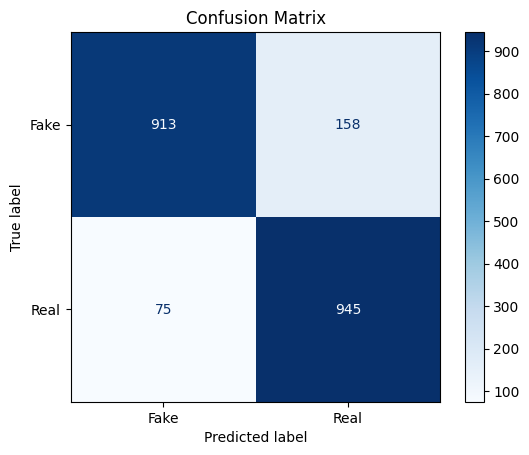

In [43]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Assuming y_test and y_predict are defined
cm = confusion_matrix(y_test, y_predict)

# Plot using ConfusionMatrixDisplay (available from sklearn 0.24+)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Fake", "Real"])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.grid(False)
plt.show()


### step 6: make a simple ui to interact with the model. Here's a simple function.

In [23]:
def news_classify():
    news = input("Enter the news: ")
    pred = model.predict(count_vectorizer.transform(([news])))
    if pred[0] == 0:
        print("Fake News.")
    else:
        print("Real News.")

In [24]:
news_classify()

Fake News.
